In [ ]:
!pip -q install koreanize-matplotlib

import matplotlib as mpl
import matplotlib.pyplot as plt
import koreanize_matplotlib  # <- 이 줄이 핵심 (import만 해도 설정됨)

# 혹시 몰라서 강제 설정(선택)
mpl.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "NanumGothic"  # 보통 colab에 잡힘

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 22.9 MB/s eta 0:00:00


In [ ]:
# 폰트 캐시 초기화(가끔 필요)
!rm -rf ~/.cache/matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import seaborn as sns
import matplotlib.pyplot as plt
!pip install koreanize-matplotlib  <- 설치 안했으면 주석풀고 하세요
import koreanize_matplotlib

Mounted at /content/drive
/bin/bash: line 1: -: No such file or directory


#프로젝트 선정 배경
- 평소 서울시 안에서 택시를 야간 시간대에 타는데 운전 기사님이 과속을 하시는 경우가 잦다는 것을 느꼈습니다.
- 특히 새벽 시간대에 과속에 대한 불편함과 사고에 대한 불안함에 공감
- 서울시 교통 데이터 중 택시 데이터가 있어 파악해볼 예정

In [ ]:
import pandas as pd
import os

folder_path = "/content/drive/MyDrive/프로젝트_주제5"
file_name = "시군구년도별시간대별총건수포함.xlsx"

path = os.path.join(folder_path, file_name)


df_시군구사고 = pd.read_excel(path)


df_시군구사고.head(10)

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,시군구,연도,합계,2021,2021.1,2021.2,2021.3,2021.4,2021.5,2021.6,...,2024.3,2024.4,2024.5,2024.6,2024.7,2024.8,2024.9,2024.10,2024.11,2024.12
0,시군구,연도,합계,합계,0시~2시,2시~4시,4시~6시,6시~8시,8시~10시,10시~12시,...,4시~6시,6시~8시,8시~10시,10시~12시,12시~14시,14시~16시,16시~18시,18시~20시,20시~22시,22시~24시
1,합계,사고[건],134887,33913,1116,544,653,1459,2951,3388,...,938,1789,3403,3559,3620,3861,4389,4430,3090,2265
2,합계,사망[명],856,243,15,16,20,30,17,27,...,17,17,13,31,15,12,16,25,22,10
3,합계,부상[명],180293,45223,1602,728,877,1846,3805,4440,...,1254,2275,4492,4753,4844,5118,5833,5654,4099,3081
4,종로구,사고[건],3657,778,31,12,16,25,74,96,...,20,52,71,104,105,106,117,122,103,63
5,종로구,사망[명],22,6,1,0,0,2,0,0,...,0,0,0,1,0,1,0,1,0,0
6,종로구,부상[명],4985,1050,43,15,20,30,89,135,...,25,63,107,174,138,137,159,150,139,91
7,중구,사고[건],3704,854,27,28,19,34,61,83,...,18,32,73,108,115,152,127,120,93,66
8,중구,사망[명],24,3,0,0,1,0,0,0,...,1,1,0,0,1,0,1,0,11,0
9,중구,부상[명],4798,1156,36,35,20,44,76,106,...,23,38,90,147,139,188,170,143,121,80


In [ ]:
import re
df1 = df_시군구사고.iloc[1:].copy()
df1.columns = df1.columns.astype(str)
df1 = df1.rename(columns={
    df1.columns[1]: "구분"
})
time_cols = [c for c in df1.columns if re.fullmatch(r"\d{4}\.\d+", c)]
df_long = df1.melt(
    id_vars=["시군구", "구분"],
    value_vars=time_cols,
    var_name="연도idx",
    value_name="건수"
)
time_labels = {
    1: "0시~2시",
    2: "2시~4시",
    3: "4시~6시",
    4: "6시~8시",
    5: "8시~10시",
    6: "10시~12시",
    7: "12시~14시",
    8: "14시~16시",
    9: "16시~18시",
    10: "18시~20시",
    11: "20시~22시",
    12: "22시~24시",
}

df_long["연도"] = df_long["연도idx"].str.split(".").str[0].astype(int)
df_long["idx"] = df_long["연도idx"].str.split(".").str[1].astype(int)
df_long["시간대"] = df_long["idx"].map(time_labels)
df_long["건수"] = (
    df_long["건수"]
    .astype(str)
    .str.replace(",", "")
)

df_long["건수"] = pd.to_numeric(df_long["건수"], errors="coerce")
df_final = df_long[["시군구", "구분", "연도", "시간대", "건수"]].copy()

df_final_시군구 = df_final.sort_values(
    ["시군구", "구분", "연도", "시간대"]
).reset_index(drop=True)

df_final_시군구.head()

,시군구,구분,연도,시간대,건수
0,강남구,부상[명],2021,0시~2시,219.0
1,강남구,부상[명],2021,10시~12시,498.0
2,강남구,부상[명],2021,12시~14시,617.0
3,강남구,부상[명],2021,14시~16시,612.0
4,강남구,부상[명],2021,16시~18시,665.0


# EDA 1. 서울에서 어느 시군구가 가장 많은 교통사고 피해자가 발생하는지?

In [ ]:
df_final_시군구['시군구'].unique()

array(['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구',
       '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구',
       '양천구', '영등포구', '용산구', '은평구', '종로구',
       '주) 부상자수 = 중상자수 + 경상자수 + 부상신고자수', '중구', '중랑구', '합계'], dtype=object)

/tmp/ipython-input-3139853289.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


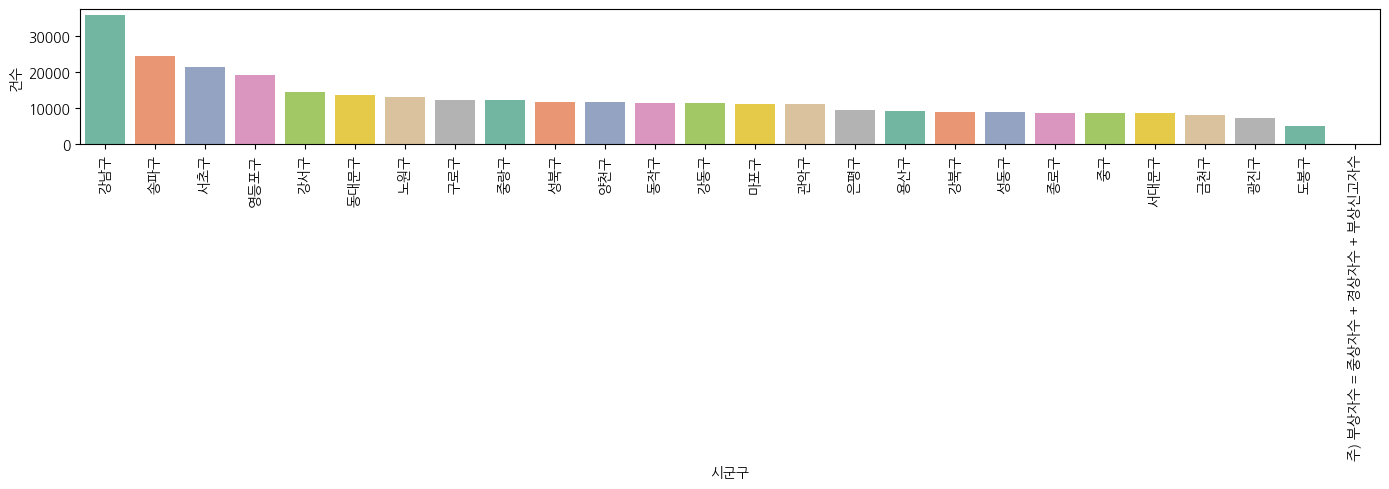

In [ ]:
import seaborn as sns
tmp = (
    df_final_시군구
    .query("시군구 != '합계'")   # ✅ 여기 핵심
    .groupby("시군구", as_index=False)["건수"]
    .sum()
    .sort_values("건수", ascending=False)
)

plt.figure(figsize=(14,5))
sns.barplot(
    data=tmp,
    x="시군구",
    y="건수",
    palette="Set2"
)

plt.xticks(rotation=90)
plt.xlabel("시군구")
plt.ylabel("건수")
plt.tight_layout()
plt.show()

2021-2024에서 사고가 가장 많이 일어난 곳은 Top 5

- 1. 강남구
- 2. 송파구
- 3. 서초구
- 4. 영등포구
- 5. 강서구

# EDA 2: 2021-2024중 가장 많이 일어난 사건 유형

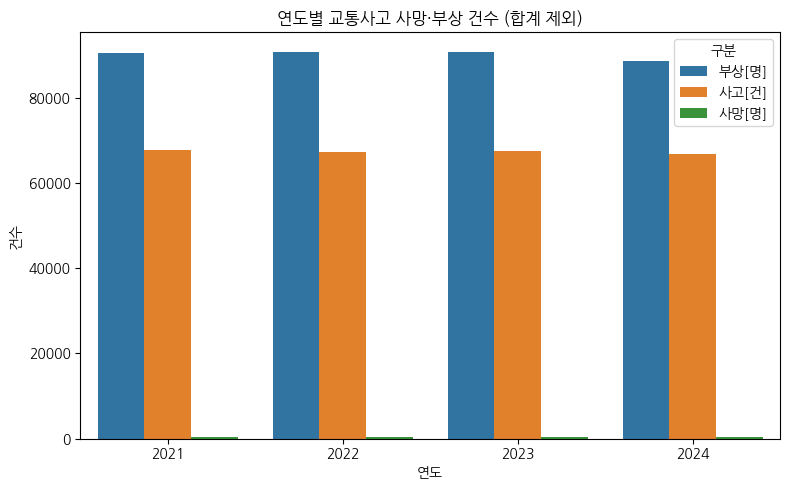

In [ ]:
yearly_damage = (
    df_final_시군구
    .query("구분 != '합계'")   # ✅ 합계 제거
    .groupby(["연도", "구분"], as_index=False)["건수"]
    .sum()
)

yearly_damage.head()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=yearly_damage,
    x="연도",
    y="건수",
    hue="구분"
)

plt.title("연도별 교통사고 사망·부상 건수 (합계 제외)")
plt.xlabel("연도")
plt.ylabel("건수")
plt.legend(title="구분")
plt.tight_layout()
plt.show()

- 아무래도 사망보다는 부상이 훨씬 많음
- 이거는 의미없을 듯

# EDA 3: 연령대별 월별 사건수 비교(가해자 시점)

In [ ]:
import pandas as pd
import os

folder_path = "/content/drive/MyDrive/코드잇_DA_13기_이현재/data"
file_name = "연령대별월별사고.xlsx"

path = os.path.join(folder_path, file_name)


df_연령대월별 = pd.read_excel(path)


df_연령대월별.head(10)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/코드잇_DA_13기_이현재/data/연령대별월별사고.xlsx'

In [ ]:
import pandas as pd
import numpy as np
import re

# df_연령대월별 = pd.read_excel(...) 로 이미 불러온 상태라고 가정

df0 = df_연령대월별.copy()

# 1) 월 라벨 행(0행) 제거
df1 = df0.iloc[1:].copy()

# 2) 컬럼명 문자열로 통일
df1.columns = df1.columns.astype(str)

# 3) 첫 2개 컬럼명 정리
df1 = df1.rename(columns={
    df1.columns[0]: "연령대",
    df1.columns[1]: "사건원본"   # 사고[건], 사망[명], 부상[명]
})

# 4) 연도/월 컬럼만 추출 (2021, 2021.1 ... 2024.12)
month_cols = [c for c in df1.columns if re.fullmatch(r"\d{4}(\.\d+)?", c)]
print("월컬럼 개수:", len(month_cols), "예시:", month_cols[:8])

# 5) 긴 형태로 변환
long = df1.melt(
    id_vars=["연령대", "사건원본"],
    value_vars=month_cols,
    var_name="연도idx",
    value_name="건수"
)

# 6) 연도 / 월(idx) 분리
long["연도"] = long["연도idx"].str.split(".").str[0].astype(int)
long["idx"] = long["연도idx"].str.split(".").str[1].fillna("0").astype(int)

# 7) idx -> 월 매핑 (0은 연간합계라서 제거할 거야)
month_map = {i: f"{i:02d}월" for i in range(1, 13)}
long["월"] = long["idx"].map(month_map)

# 연간합계(2021 같은 idx=0) 제거 → 월별만 남김
long = long[long["idx"].between(1, 12)].copy()

# 8) 건수 숫자화
long["건수"] = (
    long["건수"].astype(str)
    .str.replace(",", "", regex=False)
)
long["건수"] = pd.to_numeric(long["건수"], errors="coerce")

# 9) 사건 라벨 정리(원하면 이름 바꿔도 됨)
event_map = {"사고[건]": "총사고", "사망[명]": "사망", "부상[명]": "부상"}
long["사건"] = long["사건원본"].map(event_map).fillna(long["사건원본"])

# 10) 최종 컬럼
df_age_month_long = long[["연도", "월", "사건", "연령대", "건수"]].reset_index(drop=True)

df_age_month_long = df_age_month_long[
    df_age_month_long["사건"].isin(["사망", "부상"])
].reset_index(drop=True)
df_age_month_long = df_age_month_long[
    df_age_month_long["연령대"] != "합계"
].reset_index(drop=True)
print(df_age_month_long.info())
print("\n\n_________________________________________________________________\n\n")
df_age_month_long.head()

# 월별 연령대별 부상자수

In [ ]:
month_order = [
    "01월","02월","03월","04월","05월","06월",
    "07월","08월","09월","10월","11월","12월"
]

df_age_month_long["월"] = pd.Categorical(
    df_age_month_long["월"],
    categories=month_order,
    ordered=True
)

death_pivot = (
    df_age_month_long
    .query("사건 == '부상'")
    .groupby(["연령대", "월"], as_index=False)["건수"]
    .sum()
    .pivot(index="연령대", columns="월", values="건수")
)

plt.figure(figsize=(12,6))
sns.heatmap(
    death_pivot,
    cmap="Reds",
    linewidths=0.5,
    annot=True,
    fmt=".0f"
)

plt.title("연령대 × 월별 부상자 수 히트맵")
plt.xlabel("월")
plt.ylabel("연령대")
plt.tight_layout()
plt.show()

- 50 ~ 59세의 부상자 건수가 많다는 것을 알 수 있음
- 65세 이상이 60 ~ 64세보다 많은 것은 범위가 더 넓어서이지 않을까 싶음
- 중장년층이 사고를 많이 내는 추세

# 월별 연령대별 사망자수

In [ ]:
month_order = [
    "01월","02월","03월","04월","05월","06월",
    "07월","08월","09월","10월","11월","12월"
]

df_age_month_long["월"] = pd.Categorical(
    df_age_month_long["월"],
    categories=month_order,
    ordered=True
)

death_pivot = (
    df_age_month_long
    .query("사건 == '사망'")
    .groupby(["연령대", "월"], as_index=False)["건수"]
    .sum()
    .pivot(index="연령대", columns="월", values="건수")
)

plt.figure(figsize=(12,6))
sns.heatmap(
    death_pivot,
    cmap="Reds",
    linewidths=0.5,
    annot=True,
    fmt=".0f"
)

plt.title("연령대 × 월별 사망자 수 히트맵")
plt.xlabel("월")
plt.ylabel("연령대")
plt.tight_layout()
plt.show()

- 사망은 65세 이상이 압도적으로 강함

In [ ]:
df_final['구분'].unique()

# 부상률
- 년도별 시간대별 교통사고로 인한 부상률 확인

In [ ]:
rate_base = (
    df_final
    .pivot_table(
        index=["연도", "시간대"],
        columns="구분",
        values="건수",
        aggfunc="sum"
    )
    .reset_index()
)

rate_base.head()

In [ ]:
# 1) 원하는 시간대 순서 지정
time_order = [
    "0시~2시","2시~4시","4시~6시","6시~8시","8시~10시","10시~12시",
    "12시~14시","14시~16시","16시~18시","18시~20시","20시~22시","22시~24시"
]

# 2) rate_base에 시간대 순서(ordered category) 적용
rate_base["시간대"] = pd.Categorical(rate_base["시간대"], categories=time_order, ordered=True)

# 3) 연도별 시간대 순으로 정렬
rate_base = rate_base.sort_values(["연도", "시간대"])

# 4) 부상률(이미 계산했다면 생략 가능)
rate_base["부상률"] = rate_base["부상[명]"] / rate_base["사고[건]"].replace(0, pd.NA)

# 5) 그래프
plt.figure(figsize=(10,6))
for year in sorted(rate_base["연도"].unique()):
    tmp = rate_base[rate_base["연도"] == year]
    plt.plot(tmp["시간대"], tmp["부상률"], marker="o", label=str(year))

plt.title("연도별 시간대별 부상률")
plt.xlabel("시간대")
plt.ylabel("부상률 (부상/사고)")
plt.legend(title="연도")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 야간 시간대는 부상자 수가 상대적으로 높음을 알 수 있음
- 특히 2022년은 0-2시 부상률이 높음
- 출근 시간대인 6-8시는 부상률이 낮음(오히려 출근 시간대라 대중교통이나 다른 교통수단이 많이 지나다녀 많을 줄 알았는데 그러지는 않았음)
- 20-24시에 부상률이 올라가는 경향을 띔


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 시간대 구분
dawn_slots = ["22시~24시","0시~2시","2시~4시","4시~6시"]
AM_slots   = ["6시~8시","8시~10시","10시~12시","12시~14시"]
PM_slots   = ["14시~16시","16시~18시","18시~20시","20시~22시"]

# 1) 시간대 구분 정하기
rate_base["시간대구분"] = pd.Series(pd.NA, index=rate_base.index, dtype="string")
rate_base.loc[rate_base["시간대"].astype(str).isin(dawn_slots), "시간대구분"] = "야간"
rate_base.loc[rate_base["시간대"].astype(str).isin(AM_slots),   "시간대구분"] = "오전"
rate_base.loc[rate_base["시간대"].astype(str).isin(PM_slots),   "시간대구분"] = "오후"

# 2) KDE 그리기
plot_df = rate_base.dropna(subset=["부상률","시간대구분"]).copy()
plot_df["부상률"] = pd.to_numeric(plot_df["부상률"], errors="coerce")
plot_df = plot_df.dropna(subset=["부상률"])

plt.figure(figsize=(9,5))
sns.kdeplot(
    data=plot_df,
    x="부상률",
    hue="시간대구분",
    fill=True,
    common_norm=False,
    alpha=0.35,
    linewidth=2,
    cut=0
)

plt.title("야간 vs 오전 vs 오후 시간대 부상률 분포")
plt.xlabel("부상률 (부상/사고)")
plt.ylabel("밀도")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


# 사망률
- 년도별 시간대별 교통사고로 인한 사망률 확인

In [ ]:
# 1) 원하는 시간대 순서 지정
time_order = [
    "0시~2시","2시~4시","4시~6시","6시~8시","8시~10시","10시~12시",
    "12시~14시","14시~16시","16시~18시","18시~20시","20시~22시","22시~24시"
]

# 2) rate_base에 시간대 순서(ordered category) 적용
rate_base["시간대"] = pd.Categorical(rate_base["시간대"], categories=time_order, ordered=True)

# 3) 연도별 시간대 순으로 정렬
rate_base = rate_base.sort_values(["연도", "시간대"])

# 4) 사망률 컬럼 추가
rate_base["사망률"] = rate_base["사망[명]"] / rate_base["사고[건]"].replace(0, pd.NA)

# 5) 그래프
plt.figure(figsize=(10,6))
for year in sorted(rate_base["연도"].unique()):
    tmp = rate_base[rate_base["연도"] == year]
    plt.plot(tmp["시간대"], tmp["사망률"], marker="o", label=str(year))

plt.title("연도별 시간대별 사망률")
plt.xlabel("시간대")
plt.ylabel("사망률 (부상/사고)")
plt.legend(title="연도")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- 부상률은 야간 시간대에 2021년 가장 낮았는데 사망률은 가장 높은 것을 확인할 수 있음
- 야간 시간대에 사망률이 전반적으로 높은 경향을 띄는 것을 알 수 있음

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 시간대 구분
dawn_slots = ["22시~24시","0시~2시","2시~4시","4시~6시"]
AM_slots   = ["6시~8시","8시~10시","10시~12시","12시~14시"]
PM_slots   = ["14시~16시","16시~18시","18시~20시","20시~22시"]

# 1) 시간대 구분 정하기
rate_base["시간대구분"] = np.nan
rate_base.loc[rate_base["시간대"].astype(str).isin(dawn_slots), "시간대구분"] = "야간"
rate_base.loc[rate_base["시간대"].astype(str).isin(AM_slots),   "시간대구분"] = "오전"
rate_base.loc[rate_base["시간대"].astype(str).isin(PM_slots),   "시간대구분"] = "오후"

# 2) KDE 그리기
plot_df = rate_base.dropna(subset=["사망률","시간대구분"]).copy()
plot_df["사망률"] = pd.to_numeric(plot_df["사망률"], errors="coerce")
plot_df = plot_df.dropna(subset=["사망률"])

plt.figure(figsize=(9,5))
sns.kdeplot(
    data=plot_df,
    x="사망률",
    hue="시간대구분",
    fill=True,
    common_norm=False,
    alpha=0.35,
    linewidth=2,
    cut=0
)

plt.title("야간 vs 오전 vs 오후 시간대 사망률 분포")
plt.xlabel("사망률 (부상/사고)")
plt.ylabel("밀도")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [ ]:
def time_part(t):
    if t in ["22시~24시", "0시~2시", "2시~4시", "4시~6시"]:
        return "야간(22~06)"
    elif t in ["6시~8시", "8시~10시", "10시~12시", "12시~14시"]:
        return "오전(06~14)"
    else:
        return "오후(14~22)"

df_long["시간파트"] = df_long["시간대"].apply(time_part)

In [ ]:
df_wide = (
    df_long
    .pivot_table(
        index=["연도", "시간파트"],
        columns="구분",
        values="건수",
        aggfunc="sum"
    )
    .reset_index()
    .rename(columns={
        "사고[건]": "사고건수",
        "부상[명]": "부상자수",
        "사망[명]": "사망자수"
    })
)

df_wide["부상률"] = df_wide["부상자수"] / df_wide["사고건수"]
df_wide["사망률"] = df_wide["사망자수"] / df_wide["사고건수"]

# 가설 1: 시간대별로 부상률의 차이가 있을까?
- 귀무가설: 시간대별(오전,오후,야간) 교통사고 부상률는 차이가 없다
- 대립가설: 시간대별(오전,오후,야간) 교통사고 부상률은 차이가 있다.



In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 부상률 ANOVA
inj_night = df_wide[df_wide["시간파트"]=="야간(22~06)"]["부상률"].dropna()
inj_day   = df_wide[df_wide["시간파트"]=="오전(06~14)"]["부상률"].dropna()
inj_even  = df_wide[df_wide["시간파트"]=="오후(14~22)"]["부상률"].dropna()

f_inj, p_inj = f_oneway(inj_night, inj_day, inj_even)


print("부상률 ANOVA")
print(f"F = {f_inj:.3f}, p = {p_inj:.4f}")
# 부상률 Tukey (시간파트: 오전/오후/야간)
tukey_injury = pairwise_tukeyhsd(
    endog=df_wide["부상률"].dropna(),
    groups=df_wide.loc[df_wide["부상률"].notna(), "시간파트"],
    alpha=0.05
)
print("\n____________________________________________________________\n")
print("부상률 Tukey HSD")
print(tukey_injury)

- p-value가 0.05보다 낮으므로 귀무가설을 기각하고 대립가설을 채택한다.
- 시간대별(오전,오후,야간)교통사고 부상률은 차이가 있다.
- 부상률은 야간에서 유의하게 높고, 오전과 오후는 서로 차이가 없다.

# 가설 2: 시간대별로 사망률의 차이가 있을까?
- 귀무가설: 시간대별(오전,오후,야간) 교통사고 사망률는 차이가 없다
- 대립가설: 시간대별(오전,오후,야간) 교통사고 사망률은 차이가 있다.



In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
# 사망률 ANOVA
death_night = df_wide[df_wide["시간파트"]=="야간(22~06)"]["사망률"].dropna()
death_day   = df_wide[df_wide["시간파트"]=="오전(06~14)"]["사망률"].dropna()
death_even  = df_wide[df_wide["시간파트"]=="오후(14~22)"]["사망률"].dropna()

f_death, p_death = f_oneway(death_night, death_day, death_even)
print("\n사망률 ANOVA")
print(f"F = {f_death:.3f}, p = {p_death:.4f}")

# 사망률 Tukey (시간파트: 오전/오후/야간)
tukey_death = pairwise_tukeyhsd(
    endog=df_wide["사망률"].dropna(),
    groups=df_wide.loc[df_wide["사망률"].notna(), "시간파트"],
    alpha=0.05
)
print("\n____________________________________________________________\n")
print("사망률 Tukey HSD")
print(tukey_death)

- p-value가 0.05보다 낮으므로 귀무가설을 기각하고 대립가설을 채택한다.
- 시간대별(오전,오후,야간)교통사고 사망률은 차이가 있다.
- 사망률은 야간에서 유의하게 높고, 오전과 오후는 서로 차이가 없다.

# 데이터 전처리

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import pandas as pd

folder_path = "/content/drive/MyDrive/프로젝트_주제5"
file_name = "차랑용도별시간대별교통사고.xlsx"
path = os.path.join(folder_path, file_name)

df_raw = pd.read_excel(path, header=[0, 1])
df_raw.head()


In [ ]:
import re

print("shape:", df_raw.shape)
print("앞 10개 컬럼:", list(df_raw.columns[:10]))

# 연도(상위헤더)가 4개인지 확인
years = sorted({str(c[0]) for c in df_raw.columns if re.fullmatch(r"\d{4}", str(c[0]))})
print("연도 헤더:", years)

# 연도×시간대(합계 제외) 컬럼 뽑기
data_cols = [c for c in df_raw.columns if re.fullmatch(r"\d{4}", str(c[0])) and str(c[1]) != "합계"]
print("연도×시간대 컬럼 수:", len(data_cols), "(정상 기대: 48)")


In [ ]:
import re
import numpy as np
import pandas as pd

def clean(x):
    return (str(x).replace("\u00a0"," ").replace("\ufeff","").strip())

id1, id2 = df_raw.columns[0], df_raw.columns[1]

# 차량용도 컬럼 ffill (사망/부상 행의 NaN 채우기)
df_raw2 = df_raw.copy()
df_raw2[id1] = df_raw2[id1].astype(object).ffill()

# 연도×시간대 컬럼(합계 제외)
data_cols = [c for c in df_raw2.columns if re.fullmatch(r"\d{4}", str(c[0])) and str(c[1]) != "합계"]

df_long = (
    df_raw2.set_index([id1, id2])[data_cols]
    .stack([0, 1], future_stack=True)
    .reset_index()
)

df_long = df_long.rename(columns={
    id1: "차량용도",
    id2: "구분",
    "level_2": "연도",
    "level_3": "시간대",
    0: "건수"
})

df_long["차량용도"] = df_long["차량용도"].astype(str).map(clean)
df_long["구분"] = df_long["구분"].astype(str).map(clean)
df_long["시간대"] = df_long["시간대"].astype(str).map(clean)
df_long["연도"] = pd.to_numeric(df_long["연도"], errors="coerce").astype(int)
df_long["건수"] = pd.to_numeric(df_long["건수"], errors="coerce").fillna(0)

df_long.head()


In [ ]:
# 택시 통합
df_long["차량용도"] = df_long["차량용도"].replace({"개인택시":"택시", "법인택시":"택시"})

# 구분 3개만
keep = {"사고[건]", "사망[명]", "부상[명]"}
df_long = df_long[df_long["구분"].isin(keep)].copy()

# 전체 합계는 제외하고 싶으면 켜기
# df_long = df_long[df_long["차량용도"] != "합계"].copy()

print("차량용도 NaN 여부:", (df_long["차량용도"].isin(["nan","NaN","None"])).sum())
print("구분 unique:", df_long["구분"].unique())
print("shape:", df_long.shape)


In [ ]:
df_final2 = (
    df_long.pivot_table(
        index=["연도", "시간대", "차량용도"],
        columns="구분",
        values="건수",
        aggfunc="sum",
        dropna=False
    )
    .reset_index()
)

df_final2.columns = [clean(c) for c in df_final2.columns]
df_final2 = df_final2.rename(columns={
    "사고[건]": "사고건수",
    "사망[명]": "사망자수",
    "부상[명]": "부상자수"
})

# pivot 후 결측은 0으로(해당 조합에서 관측이 0이라는 의미)
for c in ["사고건수","사망자수","부상자수"]:
    if c not in df_final2.columns:
        df_final2[c] = 0.0
df_final2[["사고건수","사망자수","부상자수"]] = df_final2[["사고건수","사망자수","부상자수"]].fillna(0)

# 비율
df_final2["부상률"] = df_final2["부상자수"] / df_final2["사고건수"].replace(0, np.nan)
df_final2["사망률"] = df_final2["사망자수"] / df_final2["사고건수"].replace(0, np.nan)

print("df_final2 shape:", df_final2.shape)
print("부상자수 NaN 비율:", df_final2["부상자수"].isna().mean())
print("사망자수 NaN 비율:", df_final2["사망자수"].isna().mean())

df_final2.head(10)


In [ ]:
df_final2[df_final2["차량용도"]=="시내버스"].head(6)


In [ ]:
df_final2['차량용도'].unique()

In [ ]:
import numpy as np
import pandas as pd

df_focus = df_final2.copy()

# (권장) 합계 제거
df_focus = df_focus[df_focus["차량용도"] != "합계"].copy()

# 버스(시외+고속) 묶기
bus_map = {"시외버스": "버스(시외+고속)", "고속버스": "버스(시외+고속)"}
df_focus["차량용도"] = df_focus["차량용도"].replace(bus_map)

keep_veh = ["택시", "버스(시외+고속)", "시내버스", "마을버스", "이륜차", "렌터카",'승용차']
df_focus = df_focus[df_focus["차량용도"].isin(keep_veh)].copy()

# 숫자형 보정(혹시 float/object 섞였을 때 대비)
for c in ["사고건수", "부상자수", "사망자수"]:
    df_focus[c] = pd.to_numeric(df_focus[c], errors="coerce").fillna(0)

df_focus.head()


In [ ]:
df_focus['차량용도'].unique()

In [ ]:
time_order = [
    "0시~2시","2시~4시","4시~6시","6시~8시",
    "8시~10시","10시~12시","12시~14시","14시~16시",
    "16시~18시","18시~20시","20시~22시","22시~24시"
]
df_focus["시간대"] = pd.Categorical(df_focus["시간대"], categories=time_order, ordered=True)

night_slots = ["22시~24시","0시~2시","2시~4시","4시~6시"]
am_slots    = ["6시~8시","8시~10시","10시~12시","12시~14시"]
pm_slots    = ["14시~16시","16시~18시","18시~20시","20시~22시"]

df_focus["시간대구분"] = pd.Series(pd.NA, index=df_focus.index, dtype="string")
df_focus.loc[df_focus["시간대"].astype(str).isin(night_slots), "시간대구분"] = "야간"
df_focus.loc[df_focus["시간대"].astype(str).isin(am_slots),    "시간대구분"] = "오전"
df_focus.loc[df_focus["시간대"].astype(str).isin(pm_slots),    "시간대구분"] = "오후"

df_focus["시간대구분"].value_counts(dropna=False)


In [ ]:
year_agg = (
    df_focus.groupby(["연도","차량용도"], as_index=False)
    .agg({"사고건수":"sum","부상자수":"sum","사망자수":"sum"})
)

year_agg["부상률"] = year_agg["부상자수"] / year_agg["사고건수"].replace(0, np.nan)
year_agg["사망률"] = year_agg["사망자수"] / year_agg["사고건수"].replace(0, np.nan)

year_agg.head()


In [ ]:
import numpy as np
import pandas as pd

# === 1) 차량용도 필터 + 라벨 정리 ===
df_plot = df_final2.copy()
df_plot = df_plot[df_plot["차량용도"] != "합계"].copy()

# 버스(시외+고속) 묶기
bus_map = {"시외버스": "버스(시외+고속)", "고속버스": "버스(시외+고속)"}
df_plot["차량용도"] = df_plot["차량용도"].replace(bus_map)

keep_veh = ["택시", "버스(시외+고속)", "시내버스", "마을버스", "이륜차", "렌터카",'승용차']
df_plot = df_plot[df_plot["차량용도"].isin(keep_veh)].copy()

# === 2) 시간대 순서 고정 ===
time_order = [
    "0시~2시","2시~4시","4시~6시","6시~8시",
    "8시~10시","10시~12시","12시~14시","14시~16시",
    "16시~18시","18시~20시","20시~22시","22시~24시"
]
df_plot["시간대"] = pd.Categorical(df_plot["시간대"], categories=time_order, ordered=True)

# === 3) (중요) 합산 후 비율 재계산: 차량용도×연도×시간대 ===
plot_agg = (
    df_plot.groupby(["차량용도","연도","시간대"], as_index=False)
    .agg({"사고건수":"sum","부상자수":"sum","사망자수":"sum"})
)
plot_agg["부상률"] = plot_agg["부상자수"] / plot_agg["사고건수"].replace(0, np.nan)
plot_agg["사망률"] = plot_agg["사망자수"] / plot_agg["사고건수"].replace(0, np.nan)

print("plot_agg shape:", plot_agg.shape)
plot_agg.head()


# 시각화

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

veh_order = ["택시", "버스(시외+고속)", "시내버스", "마을버스", "이륜차", "렌터카",'승용차']

for veh in veh_order:
    d = plot_agg[plot_agg["차량용도"] == veh].copy()
    d = d.dropna(subset=["부상률"])  # 사고=0 구간 제외(그래프 목적)

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=d, x="시간대", y="부상률", hue="연도", marker="o",palette='Set2')

    plt.title(f"{veh} 사고 시간대별 부상률 (연도별)")
    plt.xlabel("시간대")
    plt.ylabel("부상률 (부상자수/사고건수)")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


In [ ]:
for veh in veh_order:
    d = plot_agg[plot_agg["차량용도"] == veh].copy()
    d = d.dropna(subset=["사망률"])  # 사고=0 구간 제외(그래프 목적)

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=d, x="시간대", y="사망률", hue="연도", marker="o",palette="Set2")

    plt.title(f"{veh} 사고 시간대별 사망률 (연도별)")
    plt.xlabel("시간대")
    plt.ylabel("사망률 (사망자수/사고건수)")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


# 부상률 t-test, 사망률 Z-검정

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel

veh_order = ["택시", "승용차", "버스(시외+고속)", "시내버스", "마을버스", "이륜차", "렌터카"]
comparators = [v for v in veh_order if v != "택시"]

df = plot_agg[plot_agg["차량용도"].isin(veh_order)].copy()

# 택시 부상률
taxi = df[df["차량용도"]=="택시"][["연도","시간대","부상률"]]
taxi = taxi.rename(columns={"부상률":"택시"})

rows = []
for comp in comparators:
    other = df[df["차량용도"]==comp][["연도","시간대","부상률"]]
    other = other.rename(columns={"부상률":"비교대상"})

    m = taxi.merge(other, on=["연도","시간대"], how="inner")
    x = m["택시"].to_numpy()
    y = m["비교대상"].to_numpy()

    if len(x) >= 2:
        t_stat, p = ttest_rel(x, y, nan_policy="omit")
    else:
        t_stat, p = np.nan, np.nan

    rows.append({
        "비교대상": comp,
        "n(쌍)": len(x),
        "택시 평균": np.nanmean(x) if len(x) else np.nan,
        "대상 평균": np.nanmean(y) if len(y) else np.nan,
        "차이(택시-대상)": (np.nanmean(x)-np.nanmean(y)) if len(x) else np.nan,
        "p-value": p
    })

inj_result = pd.DataFrame(rows).sort_values("p-value")
inj_result[["택시 평균","대상 평균","차이(택시-대상)"]] = inj_result[["택시 평균","대상 평균","차이(택시-대상)"]].round(4)
inj_result["p-value"] = inj_result["p-value"].map(lambda v: f"{v:.4f}" if pd.notna(v) else "")

inj_result


- 모든 교통수단과의 부상률 t-test에서 p-value가 0.05보다 낮으므로 택시가 다른 교통수단보다 부상률이 더 크다.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm

veh_order = ["택시", "승용차", "버스(시외+고속)", "시내버스", "마을버스", "이륜차", "렌터카"]
comparators = [v for v in veh_order if v != "택시"]

def two_prop_ztest(x1, n1, x2, n2):
    if n1 <= 0 or n2 <= 0:
        return np.nan, np.nan, np.nan
    p1, p2 = x1/n1, x2/n2
    p_pool = (x1 + x2) / (n1 + n2)
    if not (0 < p_pool < 1):
        return p1, p2, np.nan
    se = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
    if se <= 0 or np.isnan(se):
        return p1, p2, np.nan
    z = (p1 - p2) / se
    p = 2*(1 - norm.cdf(abs(z)))
    return p1, p2, p

df = plot_agg[plot_agg["차량용도"].isin(veh_order)].copy()

# 택시 총합(전체기간)
taxi_sum = df[df["차량용도"]=="택시"][["사고건수","사망자수"]].sum()
x1, n1 = float(taxi_sum["사망자수"]), float(taxi_sum["사고건수"])

rows = []
for comp in comparators:
    other_sum = df[df["차량용도"]==comp][["사고건수","사망자수"]].sum()
    x2, n2 = float(other_sum["사망자수"]), float(other_sum["사고건수"])

    p1, p2, p = two_prop_ztest(x1, n1, x2, n2)

    rows.append({
        "비교대상": comp,
        "택시 사망/사고": f"{int(x1)}/{int(n1)}",
        "대상 사망/사고": f"{int(x2)}/{int(n2)}",
        "택시 사망률": p1,
        "대상 사망률": p2,
        "차이(택시-대상)": (p1 - p2) if (pd.notna(p1) and pd.notna(p2)) else np.nan,
        "p-value": p
    })

death_result = pd.DataFrame(rows).sort_values("p-value")
death_result[["택시 사망률","대상 사망률","차이(택시-대상)"]] = death_result[["택시 사망률","대상 사망률","차이(택시-대상)"]].round(6)
death_result["p-value"] = death_result["p-value"].map(lambda v: f"{v:.4f}" if pd.notna(v) else "")

death_result


택시가 이륜차,마을버스,시내버스보다 사망률이 높지만 버스(시외+고속),렌터카, 승용차보단 사망률이 낮다.

# 택시 야간대 비야간대 부상률, 사망률

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel

# 시간대 구분
night_slots = ["22시~24시","0시~2시","2시~4시","4시~6시"]
am_slots    = ["6시~8시","8시~10시","10시~12시","12시~14시"]
pm_slots    = ["14시~16시","16시~18시","18시~20시","20시~22시"]
nonnight_slots = am_slots + pm_slots

df_taxi = plot_agg[plot_agg["차량용도"]=="택시"].copy()

# (연도, 시간대)별 원자료가 이미 택시 합산되어 있으므로, 시간대별 값을 그대로 사용
# 연도별로 야간 평균 vs 비야간 평균 비교 (paired: 같은 연도끼리)
night = (
    df_taxi[df_taxi["시간대"].astype(str).isin(night_slots)]
    .groupby("연도", as_index=False)["부상률"].mean()
    .rename(columns={"부상률":"야간_부상률"})
)
nonnight = (
    df_taxi[df_taxi["시간대"].astype(str).isin(nonnight_slots)]
    .groupby("연도", as_index=False)["부상률"].mean()
    .rename(columns={"부상률":"비야간_부상률"})
)

m = night.merge(nonnight, on="연도", how="inner").sort_values("연도")
x = m["야간_부상률"].to_numpy()
y = m["비야간_부상률"].to_numpy()

t_stat, p = (np.nan, np.nan)
if len(x) >= 2:
    t_stat, p = ttest_rel(x, y, nan_policy="omit")

out = pd.DataFrame([{
    "표본(연도수)": len(x),
    "야간 평균 부상률": np.nanmean(x),
    "비야간 평균 부상률": np.nanmean(y),
    "차이(야간-비야간)": np.nanmean(x) - np.nanmean(y),
    "p-value": p
}])

out[["야간 평균 부상률","비야간 평균 부상률","차이(야간-비야간)"]] = out[["야간 평균 부상률","비야간 평균 부상률","차이(야간-비야간)"]].round(4)
out["p-value"] = out["p-value"].map(lambda v: f"{v:.4f}" if pd.notna(v) else "")

print("연도별(야간/비야간) 부상률 평균 값:")
display(m.assign(
    야간_부상률=m["야간_부상률"].round(4),
    비야간_부상률=m["비야간_부상률"].round(4),
    차이=(m["야간_부상률"]-m["비야간_부상률"]).round(4)
)[["연도","야간_부상률","비야간_부상률","차이"]])

print("\n택시: 야간 vs 비야간 부상률 paired t-test 요약:")
out


:택시가 야간이 비야간대 시간보다 더 부상률이 높다.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm

night_slots = ["22시~24시","0시~2시","2시~4시","4시~6시"]
am_slots    = ["6시~8시","8시~10시","10시~12시","12시~14시"]
pm_slots    = ["14시~16시","16시~18시","18시~20시","20시~22시"]
nonnight_slots = am_slots + pm_slots

def two_prop_ztest(x1, n1, x2, n2):
    if n1 <= 0 or n2 <= 0:
        return np.nan, np.nan, np.nan
    p1, p2 = x1/n1, x2/n2
    p_pool = (x1 + x2) / (n1 + n2)
    if not (0 < p_pool < 1):
        return p1, p2, np.nan
    se = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
    if se <= 0 or np.isnan(se):
        return p1, p2, np.nan
    z = (p1 - p2) / se
    p = 2*(1 - norm.cdf(abs(z)))
    return p1, p2, p

df_taxi = plot_agg[plot_agg["차량용도"]=="택시"].copy()

night_sum = df_taxi[df_taxi["시간대"].astype(str).isin(night_slots)][["사고건수","사망자수"]].sum()
non_sum   = df_taxi[df_taxi["시간대"].astype(str).isin(nonnight_slots)][["사고건수","사망자수"]].sum()

x1, n1 = float(night_sum["사망자수"]), float(night_sum["사고건수"])
x2, n2 = float(non_sum["사망자수"]), float(non_sum["사고건수"])

p1, p2, p = two_prop_ztest(x1, n1, x2, n2)

out = pd.DataFrame([{
    "야간 사망/사고": f"{int(x1)}/{int(n1)}",
    "비야간 사망/사고": f"{int(x2)}/{int(n2)}",
    "야간 사망률": p1,
    "비야간 사망률": p2,
    "차이(야간-비야간)": (p1 - p2) if (pd.notna(p1) and pd.notna(p2)) else np.nan,
    "p-value": p
}])

out[["야간 사망률","비야간 사망률","차이(야간-비야간)"]] = out[["야간 사망률","비야간 사망률","차이(야간-비야간)"]].round(6)
out["p-value"] = out["p-value"].map(lambda v: f"{v:.4f}" if pd.notna(v) else "")

out


:택시가 야간이 비야간대 시간보다 더 사망률이 높다.

#야간대 택시 VS 차량용도별 부상률 t-test, 사망률 Z-검정

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel

veh_order = ["택시", "승용차", "버스(시외+고속)", "시내버스", "마을버스", "이륜차", "렌터카"]
comparators = [v for v in veh_order if v != "택시"]

# 야간 시간대
night_slots = ["22시~24시", "0시~2시", "2시~4시", "4시~6시"]

df = plot_agg[plot_agg["차량용도"].isin(veh_order)].copy()
df = df[df["시간대"].astype(str).isin(night_slots)].copy()   # ✅ 야간만

# 택시 부상률
taxi = df[df["차량용도"]=="택시"][["연도","시간대","부상률"]]
taxi = taxi.rename(columns={"부상률":"택시"})

rows = []
for comp in comparators:
    other = df[df["차량용도"]==comp][["연도","시간대","부상률"]]
    other = other.rename(columns={"부상률":"비교대상"})

    m = taxi.merge(other, on=["연도","시간대"], how="inner")
    x = m["택시"].to_numpy()
    y = m["비교대상"].to_numpy()

    if len(x) >= 2:
        t_stat, p = ttest_rel(x, y, nan_policy="omit")
    else:
        t_stat, p = np.nan, np.nan

    rows.append({
        "비교대상": comp,
        "n(쌍)": len(x),
        "택시 평균": np.nanmean(x) if len(x) else np.nan,
        "대상 평균": np.nanmean(y) if len(y) else np.nan,
        "차이(택시-대상)": (np.nanmean(x)-np.nanmean(y)) if len(x) else np.nan,
        "p-value": p
    })

inj_result_night = pd.DataFrame(rows).sort_values("p-value")
inj_result_night[["택시 평균","대상 평균","차이(택시-대상)"]] = inj_result_night[["택시 평균","대상 평균","차이(택시-대상)"]].round(4)
inj_result_night["p-value"] = inj_result_night["p-value"].map(lambda v: f"{v:.4f}" if pd.notna(v) else "")

inj_result_night


- 야간 시간대에서 버스를 제외한 모든 교통수단과의 부상률 t-test에서 p-value가 0.05보다 낮으므로 택시가 다른 교통수단보다 부상률이 더 크다.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm

veh_order = ["택시", "승용차", "버스(시외+고속)", "시내버스", "마을버스", "이륜차", "렌터카"]
comparators = [v for v in veh_order if v != "택시"]

# 야간 시간대
night_slots = ["22시~24시", "0시~2시", "2시~4시", "4시~6시"]

def two_prop_ztest(x1, n1, x2, n2):
    if n1 <= 0 or n2 <= 0:
        return np.nan, np.nan, np.nan
    p1, p2 = x1/n1, x2/n2
    p_pool = (x1 + x2) / (n1 + n2)
    if not (0 < p_pool < 1):
        return p1, p2, np.nan
    se = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
    if se <= 0 or np.isnan(se):
        return p1, p2, np.nan
    z = (p1 - p2) / se
    p = 2*(1 - norm.cdf(abs(z)))
    return p1, p2, p

df = plot_agg[plot_agg["차량용도"].isin(veh_order)].copy()
df = df[df["시간대"].astype(str).isin(night_slots)].copy()  # ✅ 야간만

# 택시 총합(야간만)
taxi_sum = df[df["차량용도"]=="택시"][["사고건수","사망자수"]].sum()
x1, n1 = float(taxi_sum["사망자수"]), float(taxi_sum["사고건수"])

rows = []
for comp in comparators:
    other_sum = df[df["차량용도"]==comp][["사고건수","사망자수"]].sum()
    x2, n2 = float(other_sum["사망자수"]), float(other_sum["사고건수"])

    p1, p2, p = two_prop_ztest(x1, n1, x2, n2)

    rows.append({
        "비교대상": comp,
        "택시 사망/사고(야간)": f"{int(x1)}/{int(n1)}",
        "대상 사망/사고(야간)": f"{int(x2)}/{int(n2)}",
        "택시 사망률(야간)": p1,
        "대상 사망률(야간)": p2,
        "차이(택시-대상)": (p1 - p2) if (pd.notna(p1) and pd.notna(p2)) else np.nan,
        "p-value": p
    })

death_result_night = pd.DataFrame(rows).sort_values("p-value")
death_result_night[["택시 사망률(야간)","대상 사망률(야간)","차이(택시-대상)"]] = death_result_night[["택시 사망률(야간)","대상 사망률(야간)","차이(택시-대상)"]].round(6)
death_result_night["p-value"] = death_result_night["p-value"].map(lambda v: f"{v:.4f}" if pd.notna(v) else "")

death_result_night


이륜차를 제외한 다른 교통수단은 유의하지 않다는 결론이 나온다.

이앞에는 내가 만든거

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

taxi_acc_df=pd.read_csv("/content/drive/MyDrive/코드잇_DA_13기_이현재/data/df_20212024_택시만.csv")
taxi_acc_df.shape

In [ ]:
taxi_acc_df.isnull().sum()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# month 만들기 (이미 있으면 이 줄은 생략 가능)
taxi_acc_df["month"] = pd.to_datetime(
    taxi_acc_df["발생년월"].astype(str)
      .str.replace("년 ", "-", regex=False)
      .str.replace("월", "", regex=False) + "-01",
    errors="coerce"
)

# 연도/월 분리
tmp = taxi_acc_df.dropna(subset=["month"]).copy()
tmp["연도"] = tmp["month"].dt.year
tmp["월"] = tmp["month"].dt.month

# 4개 연도만(원하면 여기 수정)
tmp = tmp[tmp["연도"].isin([2021, 2022, 2023, 2024])]

# 월(1~12) x 연도(4개)로 피벗
p = (tmp.groupby(["월","연도"])["사고건수"].sum()
       .reset_index()
       .pivot(index="월", columns="연도", values="사고건수")
       .reindex(range(1,13)))

# 라인 4개 그리기
plt.figure(figsize=(12,4))
for y in p.columns:
    plt.plot(p.index, p[y], marker="o", label=str(y))

plt.xticks(range(1,13))
plt.xlabel("월")
plt.ylabel("사고수(사고건수 합)")
plt.title("월별 사고수(연도별 4개 라인)")
plt.legend(title="연도")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# month 만들기
taxi_acc_df["month"] = pd.to_datetime(
    taxi_acc_df["발생년월"].astype(str)
      .str.replace("년 ", "-", regex=False)
      .str.replace("월", "", regex=False) + "-01",
    errors="coerce"
)

# 연도/월 분리
tmp = taxi_acc_df.dropna(subset=["month"]).copy()
tmp["연도"] = tmp["month"].dt.year
tmp["월"] = tmp["month"].dt.month

# 4개 연도
tmp = tmp[tmp["연도"].isin([2021, 2022, 2023, 2024])]

# 월(1~12) x 연도(4개)로 피벗
p = (tmp.groupby(["월","연도"])["부상신고자수"].sum()
       .reset_index()
       .pivot(index="월", columns="연도", values="부상신고자수")
       .reindex(range(1,13)))

# 라인 4개 그리기
plt.figure(figsize=(12,4))
for y in p.columns:
    plt.plot(p.index, p[y], marker="o", label=str(y))

plt.xticks(range(1,13))
plt.xlabel("월")
plt.ylabel("부상자수(부상자수 합)")
plt.title("월별 부상자수(연도별 4개 라인)")
plt.legend(title="연도")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# month 만들기 (이미 있으면 이 줄은 생략 가능)
taxi_acc_df["month"] = pd.to_datetime(
    taxi_acc_df["발생년월"].astype(str)
      .str.replace("년 ", "-", regex=False)
      .str.replace("월", "", regex=False) + "-01",
    errors="coerce"
)

# 연도/월 분리
tmp = taxi_acc_df.dropna(subset=["month"]).copy()
tmp["연도"] = tmp["month"].dt.year
tmp["월"] = tmp["month"].dt.month

# 4개 연도만(원하면 여기 수정)
tmp = tmp[tmp["연도"].isin([2021, 2022, 2023, 2024])]

# 월(1~12) x 연도(4개)로 피벗
p = (tmp.groupby(["월","연도"])["사망자수"].sum()
       .reset_index()
       .pivot(index="월", columns="연도", values="사망자수")
       .reindex(range(1,13)))

# 라인 4개 그리기
plt.figure(figsize=(12,4))
for y in p.columns:
    plt.plot(p.index, p[y], marker="o", label=str(y))

plt.xticks(range(1,13))
plt.xlabel("월")
plt.ylabel("사망자수(사망자수 합)")
plt.title("월별 사망자수(연도별 4개 라인)")
plt.legend(title="연도")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 필요 시 month 생성
taxi_acc_df["month"] = pd.to_datetime(
    taxi_acc_df["발생년월"].astype(str)
      .str.replace("년 ", "-", regex=False)
      .str.replace("월", "", regex=False) + "-01",
    errors="coerce"
)

tmp = taxi_acc_df.dropna(subset=["month"]).copy()

# ✅ 야간만 필터 (컬럼명/값이 다르면 여기만 수정)
tmp = tmp[tmp["주야"].astype(str).str.contains("야", na=False)]

tmp["연도"] = tmp["month"].dt.year
tmp["월"] = tmp["month"].dt.month
tmp = tmp[tmp["연도"].isin([2021, 2022, 2023, 2024])]

p = (tmp.groupby(["월","연도"])["사고건수"].sum()
       .reset_index()
       .pivot(index="월", columns="연도", values="사고건수")
       .reindex(range(1,13)))

plt.figure(figsize=(12,4))
for y in p.columns:
    plt.plot(p.index, p[y], marker="o", label=str(y))

plt.xticks(range(1,13))
plt.xlabel("월")
plt.ylabel("사고수(사고건수 합)")
plt.title("야간 월별 사고수(연도별)")
plt.legend(title="연도")
plt.tight_layout()
plt.show()


In [ ]:
p2 = (tmp.groupby(["월","연도"])["부상신고자수"].sum()
        .reset_index()
        .pivot(index="월", columns="연도", values="부상신고자수")
        .reindex(range(1,13)))

plt.figure(figsize=(12,4))
for y in p2.columns:
    plt.plot(p2.index, p2[y], marker="o", label=str(y))

plt.xticks(range(1,13))
plt.xlabel("월")
plt.ylabel("부상자수(부상신고자수 합)")
plt.title("야간 월별 부상자수(연도별)")
plt.legend(title="연도")
plt.tight_layout()
plt.show()


In [ ]:
taxi_acc_df['가해운전자 연령대'].unique()

In [ ]:
taxi_acc_df['가해운전자 연령대'].value_counts()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import koreanize_matplotlib

age_order = ['21-30세','31-40세','41-50세','51-60세','61-64세','65세 이상']
colors = ['#4C78A8','#F58518','#E45756','#72B7B2','#54A24B','#B279A2']
ratio = (taxi_acc_df['가해운전자 연령대']
         .value_counts(normalize=True)
         .reindex(age_order)
         .fillna(0) * 100)

ratio.plot(kind='bar', figsize=(10,4), color=colors)
plt.xlabel('가해운전자 연령대')
plt.ylabel('사고 비율(%)')
plt.title('가해운전자 연령대별 사고 비율(전체 대비)')
plt.ylim(0, ratio.max() * 1.15)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import koreanize_matplotlib

age_order = ['21-30세','31-40세','41-50세','51-60세','61-64세','65세 이상']
colors = ['#4C78A8','#F58518','#E45756','#72B7B2','#54A24B','#B279A2']

injury_col = '부상신고자수'  # ← taxi_acc_df에 이 컬럼이 있어야 함

# 1) 연령대별 부상자신고수 합계
inj_sum = (taxi_acc_df
           .groupby('가해운전자 연령대')[injury_col]
           .sum()
           .reindex(age_order)
           .fillna(0))

# 2) 전체 대비 비율(%)
total = inj_sum.sum()
ratio = (inj_sum / total * 100) if total != 0 else inj_sum * 0

# 3) 시각화
ax = ratio.plot(kind='bar', figsize=(10,4), color=colors)
ax.set_xlabel('가해운전자 연령대')
ax.set_ylabel('부상신고자수 비율(%)')
ax.set_title('가해운전자 연령대별 부상신고자수 비율(전체 대비)')
ax.set_ylim(0, ratio.max() * 1.15 if ratio.max() > 0 else 1)

# (선택) 막대 위에 값 표시
for p in ax.patches:
    v = p.get_height()
    ax.annotate(f'{v:.1f}%', (p.get_x() + p.get_width()/2, v),
                ha='center', va='bottom', fontsize=9)
ratio.plot(kind='bar', figsize=(14,8), color=colors)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import koreanize_matplotlib

age_order = ['21-30세','31-40세','41-50세','51-60세','61-64세','65세 이상']
colors = ['#4C78A8','#F58518','#E45756','#72B7B2','#54A24B','#B279A2']
ratio = (taxi_acc_df['가해운전자 연령대'][(taxi_acc_df['주야']=='야간')]
         .value_counts(normalize=True)
         .reindex(age_order)
         .fillna(0) * 100)

ratio.plot(kind='bar', figsize=(10,4), color=colors)
plt.xlabel('가해운전자 연령대')
plt.ylabel('야간 사고 비율(%)')
plt.title('가해운전자 연령대별 야간 사고 비율(전체 대비)')
plt.ylim(0, ratio.max() * 1.15)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import koreanize_matplotlib

age_order = ['21-30세','31-40세','41-50세','51-60세','61-64세','65세 이상']
colors = ['#4C78A8','#F58518','#E45756','#72B7B2','#54A24B','#B279A2']

injury_col = '부상신고자수'  # ← taxi_acc_df에 이 컬럼이 있어야 함

# 1) 연령대별 부상자신고수 합계
inj_sum = (taxi_acc_df[(taxi_acc_df['주야']=='야간')]
           .groupby('가해운전자 연령대')[injury_col]
           .sum()
           .reindex(age_order)
           .fillna(0))

# 2) 전체 대비 비율(%)
total = inj_sum.sum()
ratio = (inj_sum / total * 100) if total != 0 else inj_sum * 0

# 3) 시각화
ax = ratio.plot(kind='bar', figsize=(10,4), color=colors)
ax.set_xlabel('가해운전자 연령대')
ax.set_ylabel('야간 부상신고자수 비율(%)')
ax.set_title('가해운전자 연령대별 야간 부상신고자수 비율(전체 대비)')
ax.set_ylim(0, ratio.max() * 1.15 if ratio.max() > 0 else 1)

# (선택) 막대 위에 값 표시
for p in ax.patches:
    v = p.get_height()
    ax.annotate(f'{v:.1f}%', (p.get_x() + p.get_width()/2, v),
                ha='center', va='bottom', fontsize=9)
ratio.plot(kind='bar', figsize=(14,8), color=colors)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

age_order = ['21-30세','31-40세','41-50세','51-60세','61-64세','65세 이상']
injury_col = '부상신고자수'

df = taxi_acc_df[(taxi_acc_df['주야']=='야간') &
                 (taxi_acc_df['가해운전자 연령대'].isin(age_order))].copy()

# 사고건수 컬럼 자동 탐색(못 찾으면 직접 넣기)
acc_col = next((c for c in df.columns if ('사고' in c) and ('건' in c)), None)
if acc_col is None:
    raise KeyError("사고건수 컬럼을 못 찾았어. 예: acc_col = '사고건수' 처럼 직접 지정해줘.")

# 연/월 없이 반복 관측치 단위 자동 선택(있는 것 중 1~2개)
unit_cols = [c for c in ['시간대','시군구','구','요일','도로형태','사고유형'] if c in df.columns]
if len(unit_cols) == 0:
    raise KeyError("반복 관측치 단위 컬럼이 없어. 최소 '시간대'나 '시군구' 같은 컬럼이 필요해.")
unit_cols = unit_cols[:2]

# 관측치 단위별 부상률 생성
unit = (df.groupby(unit_cols + ['가해운전자 연령대'], as_index=False)[[injury_col, acc_col]].sum())
unit = unit[unit[acc_col] > 0].copy()
unit['부상률'] = unit[injury_col] / unit[acc_col]

# ANOVA
model = ols("Q('부상률') ~ C(Q('가해운전자 연령대'))", data=unit).fit()
anova = sm.stats.anova_lm(model, typ=2)
pval = anova.loc["C(Q('가해운전자 연령대'))", "PR(>F)"]
print("ANOVA p-value:", pval)
print("\n"+"-"*50+"\n")

# Tukey(항상 출력)
tukey = pairwise_tukeyhsd(endog=unit['부상률'],
                          groups=unit['가해운전자 연령대'],
                          alpha=0.05)
print(tukey.summary())


# ANOVA , 사후검정 결과
-  p-value가 유의하지 않은 결과가 나왓으니 귀무가설을 기각하는 것을 보류한다.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import koreanize_matplotlib

age_groups = ['51-60세','61-64세','65세 이상']
violation_col = '법규위반'   # <- 컬럼명이 다르면 여기만 수정 (예: '법규위반내용' 등)

df = taxi_acc_df.copy()
df = df[df['가해운전자 연령대'].isin(age_groups)].copy()

# 법규위반 값 정리
df[violation_col] = df[violation_col].fillna('미상').astype(str).str.strip()

# 상위 N개만 남기고 나머지는 '기타'로 묶기
top_n = 8
top = df[violation_col].value_counts().head(top_n).index
df[violation_col] = df[violation_col].where(df[violation_col].isin(top), other='기타')

# 연령대별 법규위반 구성비(%)
ct = pd.crosstab(df['가해운전자 연령대'], df[violation_col], normalize='index') * 100
ct = ct.reindex(age_groups)
ct = ct[ct.sum().sort_values(ascending=False).index]  # 항목을 전체 비중 큰 순서로

ax = ct.plot(kind='bar', stacked=True, figsize=(12,5), colormap='tab20')
ax.set_xlabel('가해운전자 연령대')
ax.set_ylabel('연령대 내 비율(%)')
ax.set_title('51세 이상 3그룹 법규위반 구성비(상위 항목 + 기타)')
ax.legend(title='법규위반', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import koreanize_matplotlib

age_groups = ['21-30세','31-40세','41-50세','51-60세','61-64세','65세 이상']
violation_col = '법규위반'   # <- 컬럼명이 다르면 여기만 수정 (예: '법규위반내용' 등)

df = taxi_acc_df.copy()
df = df[df['가해운전자 연령대'].isin(age_groups)].copy()

# 법규위반 값 정리
df[violation_col] = df[violation_col].fillna('미상').astype(str).str.strip()

# 상위 N개만 남기고 나머지는 '기타'로 묶기
top_n = 8
top = df[violation_col].value_counts().head(top_n).index
df[violation_col] = df[violation_col].where(df[violation_col].isin(top), other='기타')

# 연령대별 법규위반 구성비(%)
ct = pd.crosstab(df['가해운전자 연령대'], df[violation_col], normalize='index') * 100
ct = ct.reindex(age_groups)
ct = ct[ct.sum().sort_values(ascending=False).index]  # 항목을 전체 비중 큰 순서로

ax = ct.plot(kind='bar', stacked=True, figsize=(12,5), colormap='tab20')
ax.set_xlabel('가해운전자 연령대')
ax.set_ylabel('연령대 내 비율(%)')
ax.set_title('6그룹 법규위반 구성비(상위 항목 + 기타)')
ax.legend(title='법규위반', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

d = taxi_acc_df[['가해운전자 연령대','사고건수']].copy()
d = d.rename(columns={'가해운전자 연령대':'age', '사고건수':'y'})
d['y'] = pd.to_numeric(d['y'], errors='coerce')
d = d.dropna(subset=['age','y'])

m = smf.ols('y ~ C(age)', data=d).fit()
print("=== ANOVA (전체: 사고건수) ===")
display(sm.stats.anova_lm(m, typ=2))
print("\n"+'-'*50+'\n')
print("\n=== Tukey HSD (전체: 사고건수) ===")
print(pairwise_tukeyhsd(d['y'], d['age'], alpha=0.05).summary())


In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

d = taxi_acc_df[['가해운전자 연령대','부상신고자수']].copy()
d = d.rename(columns={'가해운전자 연령대':'age', '부상신고자수':'y'})
d['y'] = pd.to_numeric(d['y'], errors='coerce')
d = d.dropna(subset=['age','y'])

m = smf.ols('y ~ C(age)', data=d).fit()
print("=== ANOVA (전체: 부상신고자수) ===")
display(sm.stats.anova_lm(m, typ=2))
print("\n"+'-'*50+'\n')
print("\n=== Tukey HSD (전체: 부상신고자수) ===")
print(pairwise_tukeyhsd(d['y'], d['age'], alpha=0.05).summary())


In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

d = taxi_acc_df[['가해운전자 연령대','사망자수']].copy()
d = d.rename(columns={'가해운전자 연령대':'age', '사망자수':'y'})
d['y'] = pd.to_numeric(d['y'], errors='coerce')
d = d.dropna(subset=['age','y'])

m = smf.ols('y ~ C(age)', data=d).fit()
print("=== ANOVA (전체: 사망자수) ===")
display(sm.stats.anova_lm(m, typ=2))
print("\n"+'-'*50+'\n')
print("\n=== Tukey HSD (전체: 사망자수) ===")
print(pairwise_tukeyhsd(d['y'], d['age'], alpha=0.05).summary())


In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

night = taxi_acc_df[taxi_acc_df['주야'].astype(str).str.contains('야', na=False)].copy()

d = night[['가해운전자 연령대','사고건수']].copy()
d = d.rename(columns={'가해운전자 연령대':'age', '사고건수':'y'})
d['y'] = pd.to_numeric(d['y'], errors='coerce')
d = d.dropna(subset=['age','y'])

m = smf.ols('y ~ C(age)', data=d).fit()
print("=== ANOVA (야간: 사고건수) ===")
display(sm.stats.anova_lm(m, typ=2))
print("\n"+'-'*50+'\n')
print("\n=== Tukey HSD (야간: 사고건수) ===")
print(pairwise_tukeyhsd(d['y'], d['age'], alpha=0.05).summary())


In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

night = taxi_acc_df[taxi_acc_df['주야'].astype(str).str.contains('야', na=False)].copy()

d = night[['가해운전자 연령대','부상신고자수']].copy()
d = d.rename(columns={'가해운전자 연령대':'age', '부상신고자수':'y'})
d['y'] = pd.to_numeric(d['y'], errors='coerce')
d = d.dropna(subset=['age','y'])

m = smf.ols('y ~ C(age)', data=d).fit()
print("=== ANOVA (야간: 부상신고자수) ===")
display(sm.stats.anova_lm(m, typ=2))
print("\n"+'-'*50+'\n')
print("\n=== Tukey HSD (야간: 부상신고자수) ===")
print(pairwise_tukeyhsd(d['y'], d['age'], alpha=0.05).summary())


In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

night = taxi_acc_df[taxi_acc_df['주야'].astype(str).str.contains('야', na=False)].copy()

d = night[['가해운전자 연령대','사망자수']].copy()
d = d.rename(columns={'가해운전자 연령대':'age', '사망자수':'y'})
d['y'] = pd.to_numeric(d['y'], errors='coerce')
d = d.dropna(subset=['age','y'])

m = smf.ols('y ~ C(age)', data=d).fit()
print("=== ANOVA (야간: 사망자수) ===")
display(sm.stats.anova_lm(m, typ=2))
print("\n"+'-'*50+'\n')
print("\n=== Tukey HSD (야간: 사망자수) ===")
print(pairwise_tukeyhsd(d['y'], d['age'], alpha=0.05).summary())


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

age_order = ['21-30세','31-40세','41-50세','51-60세','61-64세','65세 이상']

# 1) 야간만 필터
night = taxi_acc_df[taxi_acc_df['주야'].astype(str).str.contains('야', na=False)].copy()

# 2) 연령대별 합계로 부상률 계산
g = (night.groupby('가해운전자 연령대', as_index=False)
          .agg(사고건수=('사고건수','sum'),
               부상신고자수=('부상신고자수','sum')))

g['부상률(%)'] = (g['부상신고자수'] / g['사고건수'] * 100).replace([float('inf')], 0).fillna(0)

# 3) 연령대 순서 정렬
g['가해운전자 연령대'] = pd.Categorical(g['가해운전자 연령대'], categories=age_order, ordered=True)
g = g.sort_values('가해운전자 연령대')

# 4) 시각화
plt.figure(figsize=(10,4))
plt.bar(g['가해운전자 연령대'].astype(str), g['부상률(%)'])
plt.xlabel('가해운전자 연령대')
plt.ylabel('부상률(%)  = 부상신고자수 / 사고건수')
plt.title('야간 연령대별 부상률')
plt.ylim(0, g['부상률(%)'].max() * 1.15 if g['부상률(%)'].max() > 0 else 1)

# 값 표시(원하면 유지, 싫으면 아래 2줄 삭제)
for i, v in enumerate(g['부상률(%)'].values):
    plt.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

g[['가해운전자 연령대','사고건수','부상신고자수','부상률(%)']]


In [ ]:
# ✅ [셀 0] 데이터 로드 + 한글 폰트(Colab)
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# (Colab) 한글 폰트 설치/설정
!apt-get -qq -y install fonts-nanum > /dev/null
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 데이터 로드
df = pd.read_csv("/content/drive/MyDrive/코드잇_DA_13기_이현재/data/df_step3.csv")

# 기본 정리
df.columns = df.columns.str.strip()
for c in ["시군구", "피해운전자 차종", "피해운전자 연령대"]:
    df[c] = df[c].astype(str).str.strip()

df["사고건수"] = pd.to_numeric(df["사고건수"], errors="coerce").fillna(0)

df.head()


In [ ]:
# ✅ [셀 1] 피해자(피해운전자) "차종 × 연령대" 같이 보기
import matplotlib.pyplot as plt

def sort_age(x):
    s = str(x)
    m = re.search(r"(\d+)", s)
    if m:
        return int(m.group(1))
    if any(k in s for k in ["기타", "불명", "미상", "unknown"]):
        return 10_000
    return 9_999

# 1) 연령대별 사고건수
age_tot = (df.groupby("피해운전자 연령대")["사고건수"]
           .sum()
           .sort_index(key=lambda idx: [sort_age(v) for v in idx]))

plt.figure(figsize=(10, 5))
age_tot.sort_values(ascending=True).plot(kind="barh")
plt.title("피해운전자 연령대별 사고건수(합계)")
plt.xlabel("사고건수")
plt.ylabel("연령대")
plt.tight_layout()
plt.show()

# 2) 차종별 사고건수
veh_tot = df.groupby("피해운전자 차종")["사고건수"].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
veh_tot.plot(kind="barh")
plt.title("피해운전자 차종별 사고건수(합계)")
plt.xlabel("사고건수")
plt.ylabel("차종")
plt.tight_layout()
plt.show()

# 3) 연령대 × 차종 (히트맵)
topN = 12  # 차종이 많아지면 가독성 떨어져서 상위 N개만
top_veh = df.groupby("피해운전자 차종")["사고건수"].sum().sort_values(ascending=False).head(topN).index

age_order = sorted(df["피해운전자 연령대"].unique(), key=sort_age)

pivot = (df[df["피해운전자 차종"].isin(top_veh)]
         .pivot_table(index="피해운전자 연령대",
                      columns="피해운전자 차종",
                      values="사고건수",
                      aggfunc="sum",
                      fill_value=0)
         .reindex(age_order))

plt.figure(figsize=(12, 6))
im = plt.imshow(pivot.values, aspect="auto")
plt.colorbar(im, label="사고건수")

plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=45, ha="right")
plt.yticks(range(pivot.shape[0]), pivot.index)

# 값 주석(너무 빽빽하면 주석 줄이고 싶으면 이 블록 삭제)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if v > 0:
            plt.text(j, i, int(v), ha="center", va="center", fontsize=9)

plt.title("피해운전자 연령대 × 차종 히트맵 (사고건수 합계)")
plt.tight_layout()
plt.show()


In [ ]:
# ✅ [셀 2] 시군구별 사고건수 시각화
import matplotlib.pyplot as plt

sigu = df.groupby("시군구")["사고건수"].sum().sort_values(ascending=False)

# 상위 20개(원하면 숫자 바꾸기)
top_k = 20
sigu_top = sigu.head(top_k).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sigu_top.plot(kind="barh")
plt.title(f"시군구별 사고건수 TOP {top_k} (합계)")
plt.xlabel("사고건수")
plt.ylabel("시군구")
plt.tight_layout()
plt.show()

# 전체 시군구 테이블도 같이 보고 싶으면:
display(sigu.reset_index().rename(columns={"시군구":"시군구", "사고건수":"사고건수(합계)"}))


In [ ]:
# ✅ [셀] 시군구별 "피해운전자 차종" 스택바 (사고건수 합계 기준)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 옵션 ----
top_k_sigu = 20      # 시군구 상위 몇 개만 볼지
top_m_veh = 8        # 차종 상위 몇 개만 남기고 나머지는 '기타'로 묶기(가독성)
use_100pct = False   # True면 100% 누적(비율) 스택바

# 1) 시군구 상위 top_k_sigu 선정(사고건수 합계 기준)
sigu_rank = df.groupby("시군구")["사고건수"].sum().sort_values(ascending=False)
top_sigu = sigu_rank.head(top_k_sigu).index

# 2) 차종 상위 top_m_veh 선정(전체 기준)
veh_rank = df.groupby("피해운전자 차종")["사고건수"].sum().sort_values(ascending=False)
top_veh = veh_rank.head(top_m_veh).index

# 3) 차종을 top_m_veh만 유지하고 나머지는 '기타'로 묶기
d = df[df["시군구"].isin(top_sigu)].copy()
d["차종_묶음"] = np.where(d["피해운전자 차종"].isin(top_veh), d["피해운전자 차종"], "기타")

# 4) 시군구 × 차종 pivot 생성
pivot = (d.pivot_table(index="시군구",
                       columns="차종_묶음",
                       values="사고건수",
                       aggfunc="sum",
                       fill_value=0))

# 시군구는 사고건수 합계 기준으로 정렬(상위가 위로 보이게 하려면 ascending=True로 barh)
pivot = pivot.loc[sigu_rank.loc[top_sigu].sort_values(ascending=False).index]

# 컬럼(차종)도 전체 기여도 큰 순으로 정렬(기타는 끝으로)
col_order = pivot.sum(axis=0).sort_values(ascending=False).index.tolist()
if "기타" in col_order:
    col_order = [c for c in col_order if c != "기타"] + ["기타"]
pivot = pivot[col_order]

# 5) 100% 누적 옵션
plot_data = pivot.copy()
if use_100pct:
    row_sum = plot_data.sum(axis=1).replace(0, np.nan)
    plot_data = plot_data.div(row_sum, axis=0).fillna(0) * 100

# 6) 스택바 그리기 (가독성 위해 가로 barh 추천)
fig_h = max(6, 0.35 * len(plot_data))  # 시군구 개수에 따라 자동 높이 조절
ax = plot_data.plot(kind="barh", stacked=True, figsize=(12, fig_h))

ax.set_title(f"시군구별 피해운전자 차종 스택바 (TOP {top_k_sigu} 시군구, 차종 TOP {top_m_veh} + 기타)")
ax.set_xlabel("사고건수" if not use_100pct else "비율(%)")
ax.set_ylabel("시군구")

# 범례는 바깥으로
ax.legend(title="피해운전자 차종", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [ ]:
# ✅ [셀] 지정한 10개 시군구만: "피해운전자 차종" 스택바 (사고건수 합계 기준)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 시군구 고정 리스트 ----
target_sigu = [
    "서울특별시 강남구",
    "서울특별시 강북구",
    "서울특별시 강서구",
    "서울특별시 관악구",
    "서울특별시 노원구",
    "서울특별시 동대문구",
    "서울특별시 동작구",
    "서울특별시 마포구",
    "서울특별시 서대문구",
    "서울특별시 서초구",
]

# ---- 옵션 ----
top_m_veh = 8        # 차종 상위 몇 개만 남기고 나머지는 '기타'로 묶기
use_100pct = False   # True면 100% 누적(비율) 스택바

# 1) 대상 시군구만 필터링
d = df[df["시군구"].isin(target_sigu)].copy()

# (안전) 사고건수 숫자화
d["사고건수"] = pd.to_numeric(d["사고건수"], errors="coerce").fillna(0)

# 2) 차종 상위 top_m_veh 선정(대상 시군구 내에서)
veh_rank = d.groupby("피해운전자 차종")["사고건수"].sum().sort_values(ascending=False)
top_veh = veh_rank.head(top_m_veh).index

# 3) 차종 묶기
d["차종_묶음"] = np.where(d["피해운전자 차종"].isin(top_veh), d["피해운전자 차종"], "기타")

# 4) 시군구 × 차종 pivot
pivot = (d.pivot_table(index="시군구",
                       columns="차종_묶음",
                       values="사고건수",
                       aggfunc="sum",
                       fill_value=0))

# 5) 시군구 순서: 사용자가 준 순서 그대로
pivot = pivot.reindex(target_sigu).fillna(0)

# 6) 컬럼(차종) 정렬: 기여도 큰 순 + 기타는 맨 끝
col_order = pivot.sum(axis=0).sort_values(ascending=False).index.tolist()
if "기타" in col_order:
    col_order = [c for c in col_order if c != "기타"] + ["기타"]
pivot = pivot[col_order]

# 7) 100% 누적 옵션
plot_data = pivot.copy()
if use_100pct:
    row_sum = plot_data.sum(axis=1).replace(0, np.nan)
    plot_data = plot_data.div(row_sum, axis=0).fillna(0) * 100

# 8) 스택바 (가로)
fig_h = max(6, 0.45 * len(plot_data))
ax = plot_data.plot(kind="barh", stacked=True, figsize=(12, fig_h))

ax.set_title(f"지정 10개 시군구: 피해운전자 차종 스택바 (차종 TOP {top_m_veh} + 기타)")
ax.set_xlabel("사고건수" if not use_100pct else "비율(%)")
ax.set_ylabel("시군구")

ax.legend(title="피해운전자 차종", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
